In [2]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src.scp_core import SCP
from experiments.targets import Banana_t, skewt, skewCauchy, CauchyDifference, funnel_t

In [228]:
# set up target
d = 10
# df = 2
# target = CauchyDifference(d, lbd=2)
target = skewt(a=jnp.linspace(2, 3, d), b=jnp.linspace(3, 2, d))
# target = funnel_t(d, df=df)
# target = skewCauchy(jnp.linspace(-0.5, 0.5, d))
# target = Banana_t(d=d, df=df)

(array([1.000e+00, 2.000e+00, 4.000e+00, 1.200e+01, 7.800e+01, 7.760e+02,
        6.728e+03, 2.365e+03, 3.200e+01, 1.000e+00]),
 array([-18.22104126, -15.58676546, -12.95248967, -10.31821387,
         -7.68393807,  -5.04966227,  -2.41538647,   0.21888933,
          2.85316512,   5.48744092,   8.12171672]),
 <BarContainer object of 10 artists>)

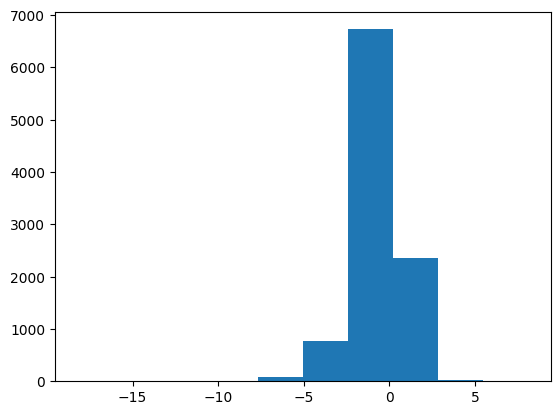

In [229]:
exact_samples = target.sample(seed=0, n=10000)
plt.hist(exact_samples[abs(exact_samples[:, 0]) < 20, 0])

In [230]:
scp_model = SCP(d, latitude=1.5) # set up SCP class
opt_params, losses = scp_model.minimize_reverse_kl(target.log_prob, seed=0, ntrain=2000, learning_rate=0.01) # optimize parameters

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2617.87it/s]


Text(0.5, 1.0, 'KL divergence vs training steps')

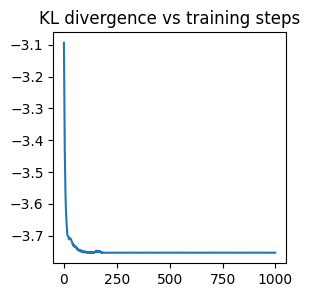

In [231]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title('KL divergence vs training steps')

In [232]:
# run MCMC
samples, accept_prob = scp_model.rwm_bright_side(target.log_prob, opt_params, seed=1, stepsize=1., nsample=1_000_000, thinning=500, algo='stepout')
print('Acceptance rate:', accept_prob)

Acceptance rate: 0.33


(-20.0, 20.0)

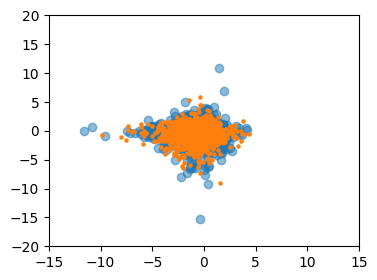

In [233]:
exact_samples = target.sample(seed=1, n=samples.shape[0])
plt.figure(figsize=(4, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5)
plt.scatter(samples[:, 0], samples[:, 1], s=5)
plt.xlim(-15, 15)
plt.ylim(-20, 20)

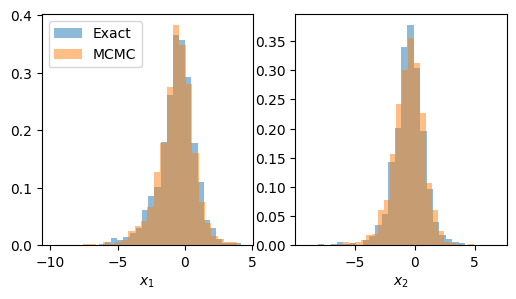

In [234]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for i in [0, 1]:
    ax[i].hist(exact_samples[abs(exact_samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='Exact')
    ax[i].hist(samples[abs(samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='MCMC')
    ax[i].set_xlabel(f'$x_{i+1}$')
ax[0].legend()

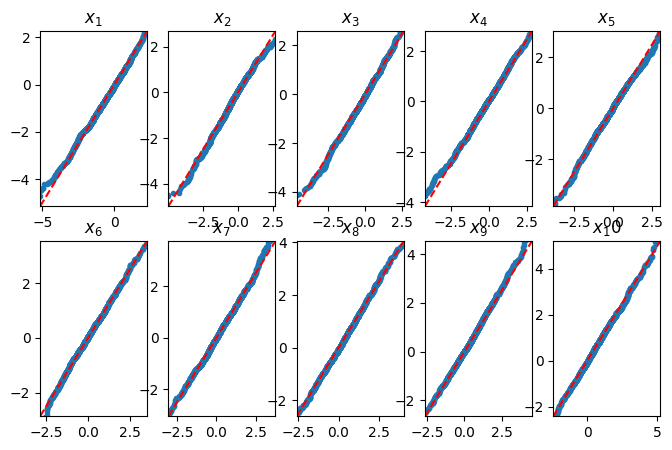

In [235]:
fig, ax = plt.subplots(2, 5, figsize=(8, 5))
for i in range(2):
    for j in range(5):
        k = i * 5 + j
        exact_sorted = jnp.sort(exact_samples[:, k])
        mcmc_sorted = jnp.sort(samples[:, k])
        ax[i, j].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
        qs = jnp.quantile(exact_samples[:, k], jnp.array([0.01, 0.99]))
        ax[i, j].set_xlim(qs)
        ax[i, j].set_ylim(qs)
        ax[i, j].plot(qs, qs, 'r--')  # Reference line for y=x
        ax[i, j].set_title(f'$x_{k+1}$')


In [236]:
samples, accept_prob = scp_model.rwm_bright_side(target.log_prob, opt_params, seed=1, stepsize=1., nsample=5_000_000, thinning=500, algo='reject')
print('Acceptance rate:', accept_prob)

Acceptance rate: 0.31239998


In [237]:
exact_samples = target.sample(seed=1, n=samples.shape[0])

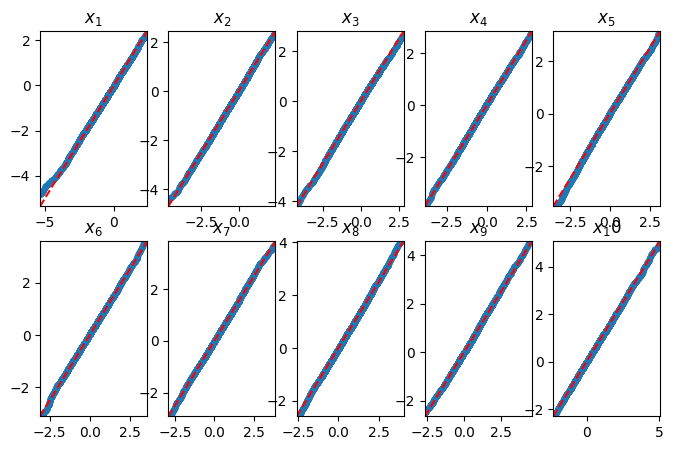

In [238]:
fig, ax = plt.subplots(2, 5, figsize=(8, 5))
for i in range(2):
    for j in range(5):
        k = i * 5 + j
        exact_sorted = jnp.sort(exact_samples[:, k])
        mcmc_sorted = jnp.sort(samples[:, k])
        ax[i, j].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
        qs = jnp.quantile(exact_samples[:, k], jnp.array([0.01, 0.99]))
        ax[i, j].set_xlim(qs)
        ax[i, j].set_ylim(qs)
        ax[i, j].plot(qs, qs, 'r--')  # Reference line for y=x
        ax[i, j].set_title(f'$x_{k+1}$')